# Takeaways & Data Pipeline Requirements

After inspecting the raw files across all modalities, the following constraints must be handled in the PyTorch `Dataset` and Data Loader:

* **Final Dataset Size:** Out of the original 794 songs, only **606 unique song IDs** contain all three required modalities (Chorus MP3, LRC Lyrics, and Dynamic Annotations). The data loader must strictly filter for these 606 IDs to prevent `FileNotFound` errors.
* **Audio Preprocessing Required:** The raw `.mp3` files are **Stereo (2 channels)** with a **Sample Rate of 44,100 Hz**. The audio processing pipeline must convert these to Mono (1 channel) and downsample them to the required rate (e.g., 16,000 Hz or 24,000 Hz for MERT).
* **Time-Series Misalignment:** The `dynamic_annotations.csv` provides target labels at  **0.5-second intervals**. On the other hand, the `.lrc` files provide sparse, event-based timestamps in a `[mm:ss.xx]` format. Further, the audio clips only contain the *chorus* (meaning annotations might start at e.g., 15.5s), while the `.lrc` files contain lyrics for the *entire* song starting from 0:00. The data loader requires an alignment algorithm to map the correct active lyric line and audio segment to the corresponding 0.5s per annotation frame.

### Data Distribution Takeaways

* **Annotations:** The targets reside within the `[0.11, 0.97]` range, necessitating `nn.Sigmoid()` on the final layer.
* **High-energy Bias:** Given the strong bias in labels with high arousal and valence, **Concordance Correlation Coefficient (CCC) Loss** is mandatory to prevent the model from lazily predicting the dataset mean.
* **Lyrics:** Lyric sequences are consistently short (mostly < 25 words). Set the tokenizer `max_length` to around 35 to optimize GPU memory without risking truncation.
* **Audio:** The significant variance in loudness risks biasing the model to equate volume with arousal. Implement **dynamic normalization** (standardizing to zero mean, unit variance) in the `Dataset` class to ensure the model focuses on content, not mastering quality.

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [54]:
import pandas as pd
import os
import librosa
import IPython.display as ipd
import re
import matplotlib.pyplot as plt
import numpy as np


Dynamic Annotations (Labels)

In [17]:
csv_path = '/content/drive/MyDrive/MER_Multimodal_Fusion/data/raw/annotations/dynamic_annotations.csv'

# Load the data into a pandas DataFrame
df_dynamic = pd.read_csv(csv_path)
song_ids = sorted(df_dynamic['musicId'].unique().tolist())

# Print the columns and the first 5 rows
print("Number of Samples:",len(df_dynamic))
print("Number of Annotated Songs:",len(song_ids))
print("Columns:", df_dynamic.columns.tolist())

Number of Samples: 36434
Number of Annotated Songs: 767
Columns: ['musicId', 'frameTime', 'Arousal(mean)', 'Valence(mean)']


In [13]:
display(df_dynamic.head())

,musicId,frameTime,Arousal(mean),Valence(mean)
0,1,15.5,0.437663,0.559975
1,1,16.0,0.437775,0.560650
2,1,16.5,0.443125,0.559900
3,1,17.0,0.442887,0.560212
4,1,17.5,0.444563,0.563337


Lyrics

In [38]:
lyrics_dir = '/content/drive/MyDrive/MER_Multimodal_Fusion/data/raw/lyrics'

lyric_files = [f for f in os.listdir(lyrics_dir) if f.endswith('.lrc')]
lyric_song_ids = sorted([int(f.replace('.lrc', '')) for f in lyric_files])

print(f"Number of lyric files: {len(lyric_files)}")

Number of lyric files: 629


In [39]:
# Grab the first available .lrc file
sample_lyric_file = lyric_files[0]
sample_lyric_path = os.path.join(lyrics_dir, sample_lyric_file)

print(f"Sample File: {sample_lyric_file}\n")

# Read and print the first 10 lines
with open(sample_lyric_path, 'r', encoding='utf-8') as file:
    for i in range(10):
        print(file.readline().strip())

Sample File: 5.lrc

[by:ismellyouonmyskin]
[00:13.45]{Hook}
[00:14.52]Young Savage, why you trappin' so hard?
[00:17.62]Why these niggas cappin' so hard?
[00:21.29]Why you got a 12 car garage?
[00:24.67]Why you pullin' all these rappers cards?
[00:28.52]Cause these niggas pussy and I'm hard
[00:31.84]I turn that ****ing soft into some hard
[00:35.12]I grew up in the streets without no heart
[00:38.59]I'm praying to my Glock and my card


Audio

In [40]:
audio_dir = '/content/drive/MyDrive/MER_Multimodal_Fusion/data/raw/chorus'

audio_files = [f for f in os.listdir(audio_dir) if f.endswith('.mp3')]
audio_song_ids = sorted([int(f.replace('.mp3', '')) for f in audio_files])

print(f"Number of audio files: {len(audio_files)}")


Number of audio files: 794


In [46]:
# Grab the first available .mp3 file
sample_audio_file = audio_files[0]
sample_audio_path = os.path.join(audio_dir, sample_audio_file)

# Load the audio (sr=None and mono=False ensures we get original sample rate & channels)
y, sr = librosa.load(sample_audio_path, sr=None, mono=False)

channels = y.shape[0]


print(f"Sample File: {sample_audio_file}\n")
print(f"Sample Rate: {sr} Hz")
if channels == 1:
    print("Audio is MONO")
else:
    print(f"Audio is STEREO (number of channels: {channels})")

# Display an audio player in the notebook
ipd.Audio(sample_audio_path)


Sample File: 808.mp3

Sample Rate: 44100 Hz
Audio is STEREO (number of channels: 2)


Song IDs with Annotations, Lyrics, and Audio

In [45]:
final_valid_ids = sorted(list(set(audio_song_ids) & set(lyric_song_ids) & set(song_ids)))

print(f"Number of songs with all 3 modalities: {len(final_valid_ids)}")
print(final_valid_ids)

Number of songs with all 3 modalities: 606
[1, 5, 6, 9, 10, 12, 17, 19, 20, 21, 23, 25, 26, 28, 32, 33, 34, 35, 37, 38, 39, 40, 42, 43, 44, 46, 48, 49, 50, 51, 52, 54, 55, 56, 57, 58, 59, 61, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 78, 79, 80, 83, 86, 87, 88, 89, 90, 92, 93, 96, 98, 100, 102, 105, 106, 107, 108, 109, 113, 114, 115, 116, 117, 119, 120, 123, 124, 126, 127, 128, 133, 135, 136, 139, 140, 141, 142, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 156, 157, 158, 159, 160, 161, 162, 166, 167, 168, 169, 170, 171, 172, 174, 175, 176, 177, 179, 180, 181, 184, 185, 186, 189, 192, 196, 197, 199, 200, 201, 202, 203, 204, 207, 209, 210, 211, 212, 215, 216, 217, 219, 220, 221, 222, 224, 225, 227, 228, 229, 230, 232, 233, 234, 235, 236, 237, 238, 239, 242, 244, 249, 251, 252, 253, 257, 260, 263, 265, 267, 269, 273, 275, 277, 279, 280, 283, 284, 285, 287, 292, 293, 294, 295, 297, 298, 299, 301, 303, 304, 305, 306, 307, 308, 309, 310, 313, 314, 319, 324, 325, 327, 329, 331, 332, 333, 3

## Data Distributions

Labels

In [47]:
# Filter out dropped songs to leave only the IDs with all 3 modalities, since these will actually be used in train/test/val
df_clean = df_dynamic[df_dynamic['musicId'].isin(final_valid_ids)]

# Extract just the min and max rows from the summary statistics
display(df_clean.describe())

,musicId,frameTime,Arousal(mean),Valence(mean)
count,28500.000000,28500.000000,28500.000000,28500.000000
mean,519.715860,30.731947,0.632286,0.607169
std,294.177011,12.301114,0.177536,0.159696
min,1.000000,15.500000,0.115763,0.126675
25%,257.000000,21.500000,0.510897,0.495866
50%,536.000000,28.000000,0.658550,0.631319
75%,777.000000,37.000000,0.777887,0.736991
max,996.000000,88.000000,0.971325,0.929687


Lyrics

NOTE: The word count per line determines the input tensor dimensions for the text encoder, ensuring memory efficiency for the fixed-size embeddings required at each time step. The words per second rate is already captured by the audio waveform, so the text encoder only needs to process the semantic content of the active lyric line. This is why we don't look at word rate distribution, but instead on word count.

In [49]:
word_counts = []

# Regex to match standard LRC timestamps so they can be removed from word count
timestamp_pattern = re.compile(r'\[\d{2}:\d{2}\.\d{2,3}\]')

for song_id in final_valid_ids:
    lrc_path = os.path.join(lyrics_dir, f"{song_id}.lrc")

    with open(lrc_path, 'r', encoding='utf-8') as f:
        for line in f:
            # Remove the timestamp and strip leading/trailing whitespace
            clean_text = re.sub(timestamp_pattern, '', line).strip()

            # If the line isn't just empty space, count the words
            if clean_text:
                word_counts.append(len(clean_text.split()))

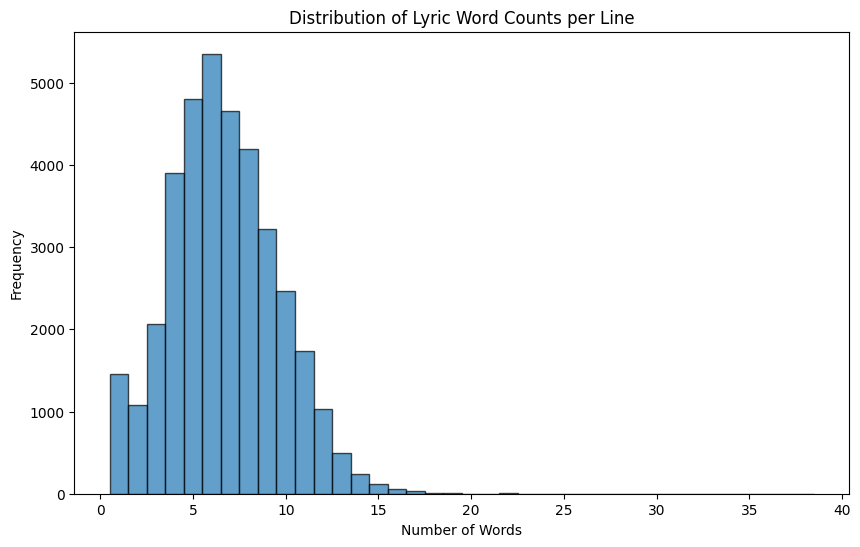

In [51]:
#convert to Pandas Series for easier handling
seq_lengths = pd.Series(word_counts)


# Create the plot
plt.figure(figsize=(10, 6))

# Use bins equal to the maximum word count to see the exact distribution
# We use align='left' so the bars represent the word count exactly
plt.hist(seq_lengths, bins=range(min(seq_lengths), max(seq_lengths) + 2),
         edgecolor='black', alpha=0.7, align='left')

plt.title('Distribution of Lyric Word Counts per Line')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.show()

Audio

In [55]:
rms_values = []

# Sample 50 songs to check for volume variance
for song_id in final_valid_ids[:50]:
    path = os.path.join(audio_dir, f"{song_id}.mp3")

    # Sample rate chosen to be consistent based on what MERT typically requires
    y, _ = librosa.load(path, sr=24000)

    # Calculate Root Mean Square amplitude
    rms = np.sqrt(np.mean(y**2))
    rms_values.append(rms)

Mean: 0.2698
Standard Deviation: 0.0610


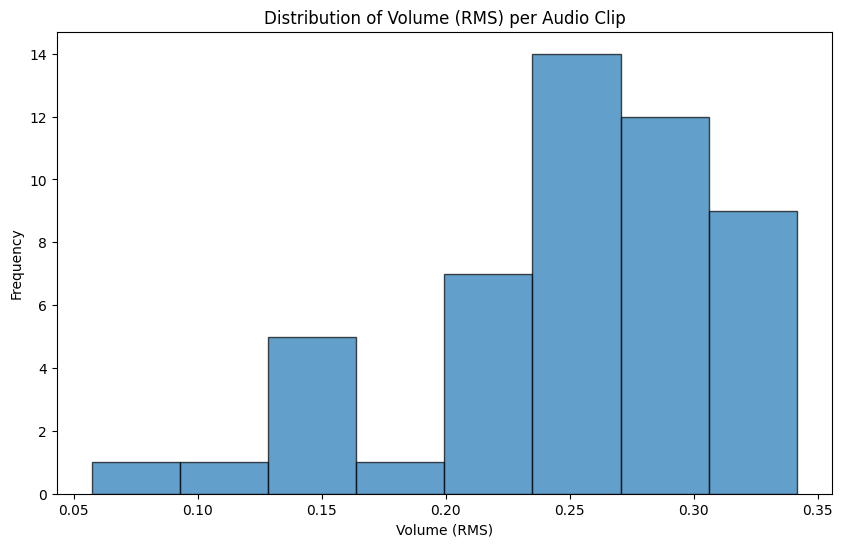

In [59]:
#convert to Pandas Series for easier handling
audio_rmses = pd.Series(rms_values)

print(f"Mean: {audio_rmses.mean():.4f}")
print(f"Standard Deviation: {audio_rmses.std():.4f}")


# Create the plot
plt.figure(figsize=(10, 6))

plt.hist(audio_rmses, bins="auto", edgecolor='black', alpha=0.7, align='left')

plt.title('Distribution of Volume (RMS) per Audio Clip')
plt.xlabel('Volume (RMS)')
plt.ylabel('Frequency')

plt.show()